# WildChat / LMSYS-Chat-1M — Conversation Unpacking, Feature Engineering, and Weakly-Supervised Satisfaction Prediction

This notebook is designed for **large-scale chat datasets** where each row contains a full conversation (a list of turns).  
It focuses on:

- **Robust conversation unpacking** (fixes the common “didn’t correctly unpack” issue)
- **Efficient EDA** (sampling + streaming + chunk-friendly patterns)
- **Turn-level features**: sentiment trajectory, topic drift, user→assistant alignment, latency (if timestamps exist)
- **Conversation-level features**: turn count, coherence, escalation proxies
- **Satisfaction prediction** framed as a **classification task** using **weak labels** (because public releases typically lack explicit user satisfaction)

Supported datasets:
- **WildChat** (`allenai/WildChat`)  
- **LMSYS-Chat-1M** (`lmsys/lmsys-chat-1m`) — may require accepting a license agreement.

> Tip: Start with a sample (e.g., 50k conversations) so cells don’t “take forever”. Scale up only after validating the pipeline.


## 0) Environment setup

If you run into missing packages, uncomment the installation cell.

Recommended runtime: Python 3.10+.


In [1]:

# Uncomment if needed:
# %pip -q install datasets pyarrow pandas numpy scikit-learn nltk tqdm matplotlib

import os
import re
import json
import ast
import math
import time
import numpy as np
import pandas as pd

from datetime import datetime, timezone
from typing import Any, Dict, List, Optional, Tuple

import matplotlib.pyplot as plt

from tqdm.auto import tqdm

# ML
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

from sklearn.feature_extraction.text import HashingVectorizer


## 1) Configuration

Choose dataset + loading mode. For **very large** datasets, prefer:

- `streaming=True` (does not download the entire dataset into RAM)


In [ ]:

DATASET_CHOICE = "wildchat"   # "wildchat" or "lmsys"
SPLIT = "train"              # many HF datasets only have "train"
STREAMING = True             # recommended for large data
RANDOM_SEED = 0

np.random.seed(RANDOM_SEED)


## 2) Load dataset (streaming + safe sampling)

This section loads a **DataFrame of conversations**.  

If you already have a local parquet/csv, you can skip HF loading and read your file directly.


In [2]:
from google.colab import drive

drive.mount("/content/drive", force_remount=False)
print("✅ Google Drive mounted at /content/drive")

Mounted at /content/drive
✅ Google Drive mounted at /content/drive


In [3]:
import os
import time
import pandas as pd
from datasets import load_dataset, load_from_disk

# ── Configuration ─────────────────────────────────────────────────────────────
GDRIVE_DATASET_DIR = "/content/drive/MyDrive/datasets/wildchat"
# Note: Changing extension to a folder name, as save_to_disk creates a directory
CACHE_PATH = os.path.join(GDRIVE_DATASET_DIR, "wildchat_full_cache")

def load_from_drive(path: str) -> pd.DataFrame:
    """Load the cached HuggingFace dataset from Google Drive."""
    print(f"📂 Cache hit — loading from Drive:\n   {path}")
    t0 = time.time()
    dataset = load_from_disk(path)
    df = dataset.to_pandas()
    print(f"✅ Loaded {len(df):,} rows in {time.time() - t0:.1f}s")
    return df

def download_and_cache(path: str) -> pd.DataFrame:
    """Download full dataset, cache natively to Drive, and return DataFrame."""
    print("🌐 Cache miss — downloading from HuggingFace …")
    t0 = time.time()

    # Download dataset
    hf_dataset = load_dataset("allenai/WildChat-1M", split="train")
    print(f"   Downloaded {len(hf_dataset):,} rows in {time.time() - t0:.1f}s")

    # Save to drive preserving all nested structures natively
    os.makedirs(os.path.dirname(path), exist_ok=True)
    t1 = time.time()
    hf_dataset.save_to_disk(path)
    print(f"💾 Saved to Drive → {path}")
    print(f"   Write time: {time.time() - t1:.1f}s")

    return hf_dataset.to_pandas()

# ── Smart loader: Drive cache → HuggingFace fallback ─────────────────────────
if os.path.exists(CACHE_PATH):
    df_raw = load_from_drive(CACHE_PATH)
else:
    df_raw = download_and_cache(CACHE_PATH)

print(f"\n📋 Shape   : {df_raw.shape}")
print(f"   Columns : {df_raw.columns.tolist()}")

📂 Cache hit — loading from Drive:
   /content/drive/MyDrive/datasets/wildchat/wildchat_full_cache
✅ Loaded 837,989 rows in 121.0s

📋 Shape   : (837989, 14)
   Columns : ['conversation_hash', 'model', 'timestamp', 'conversation', 'turn', 'language', 'openai_moderation', 'detoxify_moderation', 'toxic', 'redacted', 'state', 'country', 'hashed_ip', 'header']


In [4]:
df_raw.head(5)

,conversation_hash,model,timestamp,conversation,turn,language,openai_moderation,detoxify_moderation,toxic,redacted,state,country,hashed_ip,header
0,c9ec5b440fbdd2a269333dd241f32f64,gpt-4-0314,2023-04-09 00:02:53+00:00,[{'content': 'Hey there! Are you familiar with...,1,English,"[{'categories': {'harassment': False, 'harassm...","[{'identity_attack': 0.00020589135237969458, '...",False,False,Texas,United States,22fd87ba9b98f3d379b23c7b52961f2d4a8505127e58b3...,"{'accept-language': 'en-US,en;q=0.9,es;q=0.8',..."
1,34f1581760df304d539e2fe4653b40d3,gpt-4-0314,2023-04-09 00:03:20+00:00,[{'content': 'Crea una imagen de una mujer cor...,2,Spanish,"[{'categories': {'harassment': False, 'harassm...","[{'identity_attack': 0.007170863449573517, 'in...",False,False,A Coruña,Spain,58369722cd0bdf7fc027a67491ba65b74576df6994c36c...,"{'accept-language': 'es-ES,es;q=0.9,en;q=0.8',..."
2,cf1267ca6b2f6fccc9c36652a00059a1,gpt-4-0314,2023-04-09 00:04:52+00:00,"[{'content': 'Old age PT hx of DM, HTN, dyslip...",1,English,"[{'categories': {'harassment': False, 'harassm...","[{'identity_attack': 0.0002258022577734664, 'i...",False,False,Mecca Region,Saudi Arabia,8133108d1c433c180c6be8302dc5a6681f2bec980190a1...,"{'accept-language': 'en-US,en;q=0.9', 'user-ag..."
3,7f1c97a4f873cda8106b010d040be078,gpt-4-0314,2023-04-09 00:06:29+00:00,[{'content': 'calcula la mediana de followers:...,1,Catalan,"[{'categories': {'harassment': False, 'harassm...","[{'identity_attack': 0.0003390185011085123, 'i...",False,False,Barcelona,Spain,846e43fb5fbb4b8cfbafa17083387aad62e58f5fb23482...,"{'accept-language': 'es,es-ES;q=0.9,en;q=0.8,e..."
4,e98d3e74c57f9a65261df393d9124ac2,gpt-4-0314,2023-04-09 00:06:49+00:00,[{'content': 'Hey there! Are you familiar with...,1,English,"[{'categories': {'harassment': False, 'harassm...","[{'identity_attack': 0.00020642601884901524, '...",False,False,Texas,United States,22fd87ba9b98f3d379b23c7b52961f2d4a8505127e58b3...,"{'accept-language': 'en-US,en;q=0.9,es;q=0.8',..."


## 3) Quick schema + sanity checks

In [5]:
# Basic missingness summary (top columns)
missing = (df_raw.isna().mean().sort_values(ascending=False) * 100).round(2)
missing.head(20)

,0
state,19.47
country,0.13
timestamp,0.00
conversation,0.00
conversation_hash,0.00
model,0.00
language,0.00
turn,0.00
openai_moderation,0.00
detoxify_moderation,0.00


In [7]:
# Peek at the first row to see the raw structure
example_raw = df_raw["conversation"].iloc[0]
type(example_raw), str(example_raw)[:500]


(numpy.ndarray,
 "[{'content': 'Hey there! Are you familiar with reality shifting? So, I’m refining a foolproof method for reality shifting and want to pick a destination. Want to help me? I’m thinking something pretty personalized. There are a few things that are required of my destination. 1. The quest. I have to have a clear overarching goal in my reality, and don’t make it too crazy. It should be more along the lines of “save the president’s daughter” or “escape this weird wacky sinister place” NOT “get an ar")

## 4) Robust conversation unpacking (FIX)

Conversations in Arrow→pandas can appear as:
- list of dicts (ideal)
- dict of lists (columnar struct)
- numpy arrays
- JSON strings

We normalize everything into `List[Dict]`.


In [9]:

from functools import lru_cache

@lru_cache(maxsize=200_000)
def _parse_cached(s: str):
    # caching helps if duplicate strings appear
    try:
        return json.loads(s)
    except Exception:
        return ast.literal_eval(s)

def _maybe_parse_jsonish(x):
    if isinstance(x, str):
        s = x.strip()
        if s and s[0] in "[{":
            try:
                return _parse_cached(s)
            except Exception:
                return x
    return x

def normalize_conversation(conv: Any) -> List[Dict[str, Any]]:
    """Always returns list[dict] turns, regardless of storage format."""
    conv = _maybe_parse_jsonish(conv)

    if isinstance(conv, np.ndarray):
        conv = conv.tolist()

    # dict-of-lists -> list-of-dicts
    if isinstance(conv, dict):
        keys = list(conv.keys())
        if not keys:
            return []
        # Determine number of turns as max length among list-like fields
        lengths = []
        for k in keys:
            v = conv.get(k)
            if isinstance(v, (list, tuple, np.ndarray)):
                lengths.append(len(v))
        n = max(lengths) if lengths else 0
        turns = []
        for j in range(n):
            t = {}
            for k in keys:
                v = conv.get(k)
                if isinstance(v, (list, tuple, np.ndarray)):
                    t[k] = v[j] if j < len(v) else None
                else:
                    t[k] = v
            if isinstance(t, dict):
                turns.append(t)
        return turns

    # list-of-dicts
    if isinstance(conv, list):
        return [t for t in conv if isinstance(t, dict)]

    return []

# Test normalization on a few examples
for idx in [0, 1, 2]:
    if idx >= len(df_raw): break
    turns = normalize_conversation(df_raw["conversation"].iloc[idx])
    print(idx, "turns:", len(turns), "| first roles:", [t.get("role") for t in turns[:4]])


0 turns: 2 | first roles: ['user', 'assistant']
1 turns: 4 | first roles: ['user', 'assistant', 'user', 'assistant']
2 turns: 2 | first roles: ['user', 'assistant']


### Inspect one normalized conversation (should show correct turns)

In [10]:

idx = 0
turns = normalize_conversation(df_raw["conversation"].iloc[idx])
print("Turns:", len(turns))
for t in turns[:6]:
    role = (t.get("role") or "?").upper()
    content = (t.get("content") or "")
    content_short = content[:220].replace("\n", " ")
    print(f"[{role}] {content_short}\n")


Turns: 2
[USER] Hey there! Are you familiar with reality shifting? So, I’m refining a foolproof method for reality shifting and want to pick a destination. Want to help me? I’m thinking something pretty personalized. There are a few thi

[ASSISTANT] Hey there! I'm more than happy to help you plan your reality-shifting adventure, and I've got just the destination in mind for you based on your requirements. Let's dive in, shall we?  Welcome to the breathtaking world o



## 5) Efficient EDA: conversation size, language, toxicity flags

We do EDA on the loaded dataset.  
For full-scale processing (~1M rows), run in chunks or use streaming + incremental aggregation.


In [11]:

def conv_basic_features_fast(conv: Any) -> Tuple[int,int,int,int,int,float,bool,bool]:
    turns = normalize_conversation(conv)

    total_turns = len(turns)
    user_turns = 0
    asst_turns = 0
    user_chars = 0
    asst_chars = 0
    has_toxic = False
    has_redacted = False

    for t in turns:
        role = t.get("role")
        c = t.get("content")
        l = len(c) if isinstance(c, str) else 0

        if role == "user":
            user_turns += 1
            user_chars += l
        elif role == "assistant":
            asst_turns += 1
            asst_chars += l

        if t.get("toxic") is True:
            has_toxic = True
        if t.get("redacted") is True:
            has_redacted = True

    denom = user_chars if user_chars else 1
    gen_ratio = asst_chars / denom
    return total_turns, user_turns, asst_turns, user_chars, asst_chars, gen_ratio, has_toxic, has_redacted

feat_cols = [
    "total_turns","n_user_turns","n_asst_turns",
    "user_char_len","asst_char_len","generation_ratio",
    "contains_toxic_msg","contains_redacted_msg"
]

features = [conv_basic_features_fast(c) for c in tqdm(df_raw[conv_col].values, desc="Basic conv features")]
feat_df = pd.DataFrame(features, columns=feat_cols)

df = pd.concat([df_raw.reset_index(drop=True), feat_df], axis=1)
df.head(2)


Basic conv features:   0%|          | 0/837989 [00:00<?, ?it/s]

,conversation_hash,model,timestamp,conversation,turn,language,openai_moderation,detoxify_moderation,toxic,redacted,...,hashed_ip,header,total_turns,n_user_turns,n_asst_turns,user_char_len,asst_char_len,generation_ratio,contains_toxic_msg,contains_redacted_msg
0,c9ec5b440fbdd2a269333dd241f32f64,gpt-4-0314,2023-04-09 00:02:53+00:00,[{'content': 'Hey there! Are you familiar with...,1,English,"[{'categories': {'harassment': False, 'harassm...","[{'identity_attack': 0.00020589135237969458, '...",False,False,...,22fd87ba9b98f3d379b23c7b52961f2d4a8505127e58b3...,"{'accept-language': 'en-US,en;q=0.9,es;q=0.8',...",2,1,1,1373,3069,2.235251,False,False
1,34f1581760df304d539e2fe4653b40d3,gpt-4-0314,2023-04-09 00:03:20+00:00,[{'content': 'Crea una imagen de una mujer cor...,2,Spanish,"[{'categories': {'harassment': False, 'harassm...","[{'identity_attack': 0.007170863449573517, 'in...",False,False,...,58369722cd0bdf7fc027a67491ba65b74576df6994c36c...,"{'accept-language': 'es-ES,es;q=0.9,en;q=0.8',...",4,2,2,145,1748,12.055172,False,False


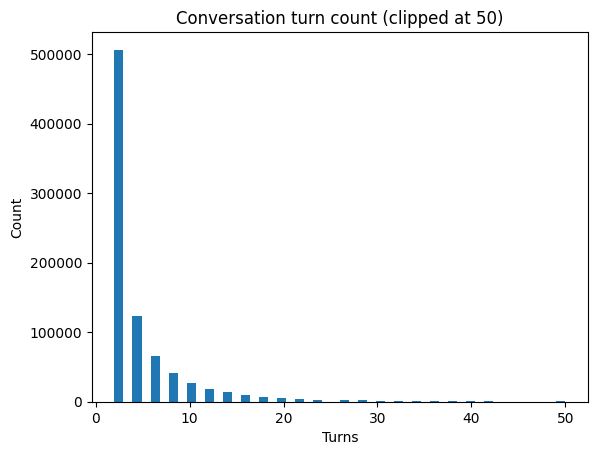

,count,mean,std,min,25%,50%,75%,max
total_turns,837989.0,4.678042,6.029338,2.000000,2.000000,2.000000,4.000000,498.0
n_user_turns,837989.0,2.339021,3.014669,1.000000,1.000000,1.000000,2.000000,249.0
n_asst_turns,837989.0,2.339021,3.014669,1.000000,1.000000,1.000000,2.000000,249.0
user_char_len,837989.0,2088.438342,8273.973818,0.000000,88.000000,320.000000,1922.000000,598067.0
asst_char_len,837989.0,3113.847516,5027.635490,1.000000,817.000000,1937.000000,3489.000000,461479.0
generation_ratio,837989.0,16.443953,85.337970,0.000005,0.930716,5.333333,18.351955,28553.0


In [12]:

# Distributions
fig, ax = plt.subplots()
ax.hist(df["total_turns"].clip(upper=50), bins=50)
ax.set_title("Conversation turn count (clipped at 50)")
ax.set_xlabel("Turns"); ax.set_ylabel("Count")
plt.show()

df[feat_cols].describe().T


In [13]:

# Language distribution if present in turns (WildChat: per message). We'll estimate language by first user turn.
def first_user_language(conv: Any) -> Optional[str]:
    for t in normalize_conversation(conv):
        if t.get("role") == "user":
            return t.get("language")
    return None

df["first_user_language"] = [first_user_language(c) for c in tqdm(df["conversation"].values, desc="First user language")]
df["first_user_language"].value_counts(dropna=False).head(20)


First user language:   0%|          | 0/837989 [00:00<?, ?it/s]

,count
first_user_language,
English,469425
Chinese,113378
Russian,83418
French,26099
Spanish,19045
German,17217
Arabic,11252
Portuguese,9602
Maori,8968


## 6) Build a turn-level DataFrame (safe + bounded)

**Important:** exploding 1M conversations can yield **many millions of turns**.  


In [16]:

def get_conversation_id(df: pd.DataFrame) -> np.ndarray:
    # Prefer an existing id/hash column if present
    for c in ["conversation_id", "id", "conv_id", "hash", "conversation_hash"]:
        if c in df.columns:
            return df[c].values
    # fallback: row index
    return np.arange(len(df))

def build_turn_df(df_conv: pd.DataFrame,
                  conv_col: str) -> pd.DataFrame:
    conv_ids = get_conversation_id(df_conv)
    records = []
    append = records.append
    norm = normalize_conversation

    for i, conv in enumerate(tqdm(df_conv[conv_col].values, desc="Exploding to turns")):
        cid = conv_ids[i]
        turns = norm(conv)
        for j, t in enumerate(turns):
            append({
                "conversation_id": cid,
                "turn_index": j,
                "role": t.get("role"),
                "content": t.get("content"),
                "language": t.get("language"),
                "toxic": t.get("toxic"),
                "redacted": t.get("redacted"),
                # keep any timestamp-ish fields if they exist
                "timestamp": t.get("timestamp", None) if isinstance(t, dict) else None,
            })

    return pd.DataFrame.from_records(records)

turn_df = build_turn_df(df, conv_col="conversation")
turn_df.head(5)


Exploding to turns:   0%|          | 0/837989 [00:00<?, ?it/s]

,conversation_id,turn_index,role,content,language,toxic,redacted,timestamp
0,c9ec5b440fbdd2a269333dd241f32f64,0,user,Hey there! Are you familiar with reality shift...,English,False,False,NaT
1,c9ec5b440fbdd2a269333dd241f32f64,1,assistant,Hey there! I'm more than happy to help you pla...,English,False,False,2023-04-09 00:02:53+00:00
2,34f1581760df304d539e2fe4653b40d3,0,user,Crea una imagen de una mujer corriente por la ...,Spanish,False,False,NaT
3,34f1581760df304d539e2fe4653b40d3,1,assistant,"Como inteligencia artificial basada en texto, ...",Spanish,False,False,2023-04-09 00:01:51+00:00
4,34f1581760df304d539e2fe4653b40d3,2,user,Aceede a Amazon y dame una lista de lo TV más ...,Spanish,False,False,NaT


In [17]:

turn_df["role"].value_counts(dropna=False)


,count
role,
user,1960074
assistant,1960074


## 7) Turn-level features

We compute lightweight per-turn features:

- length stats
- question markers
- sentiment (VADER for English-ish text; will still produce a score for other languages but interpret cautiously)
- refusal indicators (simple heuristic)


In [ ]:

# Basic text features
def safe_str(x):
    return x if isinstance(x, str) else ""

turn_df["content"] = turn_df["content"].map(safe_str)

turn_df["char_len"] = turn_df["content"].str.len()
turn_df["word_len"] = turn_df["content"].str.split().map(len)
turn_df["has_qmark"] = turn_df["content"].str.contains(r"\?")
turn_df["n_qmark"] = turn_df["content"].str.count(r"\?")
turn_df["exclam"] = turn_df["content"].str.count(r"!")
turn_df["newline"] = turn_df["content"].str.count(r"\n")

# Simple refusal markers (extend as needed)
REFUSAL_PAT = re.compile(r"\b(i\s+can\'?t|i\s+cannot|i\s+won\'?t|sorry,?\s+i\s+can\'?t|i\s+am\s+unable)\b", re.I)
turn_df["has_refusal"] = turn_df["content"].str.contains(REFUSAL_PAT)

turn_df.head(3)


In [ ]:

# Sentiment: VADER (fast baseline)
import nltk
from nltk.sentiment import SentimentIntensityAnalyzer

try:
    _ = nltk.data.find("sentiment/vader_lexicon.zip")
except LookupError:
    nltk.download("vader_lexicon")

SIA = SentimentIntensityAnalyzer()

def vader_compound(text: str) -> float:
    if not text or not text.strip():
        return 0.0
    return float(SIA.polarity_scores(text)["compound"])

turn_df["sentiment"] = [vader_compound(t) for t in tqdm(turn_df["content"].values, desc="VADER sentiment")]
turn_df[["role","sentiment","content"]].head(5)


## 8) Response latency patterns (if timestamps exist)

Some datasets include timestamps at the turn-level; others don’t.

We attempt to parse timestamps from common fields:
- `timestamp`, `created_at`, `tstamp`  
and compute latency from a user message to the immediately following assistant message.


In [ ]:

def parse_timestamp(x) -> Optional[float]:
    """Return UNIX seconds if possible; else None."""
    if x is None or (isinstance(x, float) and math.isnan(x)):
        return None

    # Numeric: could be seconds or milliseconds
    if isinstance(x, (int, float)) and not isinstance(x, bool):
        v = float(x)
        # Heuristic: if it's too large, treat as ms
        if v > 1e12:
            return v / 1000.0
        if v > 1e10:  # some ms values smaller
            return v / 1000.0
        # assume seconds
        return v

    # String: ISO or other formats
    if isinstance(x, str):
        s = x.strip()
        if not s:
            return None
        # Try ISO 8601
        try:
            dt = datetime.fromisoformat(s.replace("Z", "+00:00"))
            if dt.tzinfo is None:
                dt = dt.replace(tzinfo=timezone.utc)
            return dt.timestamp()
        except Exception:
            pass

        # Try numeric string
        try:
            v = float(s)
            return parse_timestamp(v)
        except Exception:
            return None

    return None

# Choose best available timestamp field
ts = []
for a,b,c in zip(turn_df.get("timestamp"), turn_df.get("created_at"), turn_df.get("tstamp")):
    t = parse_timestamp(a)
    if t is None: t = parse_timestamp(b)
    if t is None: t = parse_timestamp(c)
    ts.append(t)

turn_df["ts_unix"] = ts

turn_df["has_ts"] = turn_df["ts_unix"].notna()
turn_df["has_ts"].value_counts()


In [ ]:

# Latency: user -> next assistant (within each conversation)
turn_df = turn_df.sort_values(["conversation_id","turn_index"]).reset_index(drop=True)

# compute adjacency latency; only valid if adjacent turns are user then assistant and timestamps exist
turn_df["prev_role"] = turn_df.groupby("conversation_id")["role"].shift(1)
turn_df["prev_ts"] = turn_df.groupby("conversation_id")["ts_unix"].shift(1)

turn_df["latency_sec"] = np.where(
    (turn_df["role"] == "assistant") &
    (turn_df["prev_role"] == "user") &
    turn_df["ts_unix"].notna() & turn_df["prev_ts"].notna(),
    turn_df["ts_unix"] - turn_df["prev_ts"],
    np.nan
)

turn_df["latency_sec"].describe()


## 9) Topic drift + QA alignment (fast hashing vectorization)

We avoid fitting TF-IDF per conversation (slow).  
Instead we use a **HashingVectorizer** (no fitting), and compute cosine similarities via dot-products.

### Metrics
- **Adjacent similarity** between consecutive turns (proxy for coherence)
- **User→Assistant alignment**: similarity of assistant turn to previous user turn
- **User drift**: 1 - similarity between consecutive user turns


In [ ]:

HV = HashingVectorizer(
    n_features=2**18,
    alternate_sign=False,
    norm="l2",
    ngram_range=(1,2),
    lowercase=True
)

X = HV.transform(turn_df["content"].values)

# Adjacent cosine similarity across full turn_df order
# For L2-normalized vectors, cosine = dot product
adj_sim = np.array(X[:-1].multiply(X[1:]).sum(axis=1)).ravel()

turn_df["adjacent_sim"] = np.nan
turn_df.loc[1:, "adjacent_sim"] = adj_sim  # similarity to previous row in the sorted frame

# Remove cross-conversation adjacency effects
conv_changed = turn_df["conversation_id"].values[1:] != turn_df["conversation_id"].values[:-1]
turn_df.loc[np.where(conv_changed)[0] + 1, "adjacent_sim"] = np.nan

# User->Assistant alignment: assistant row's similarity to previous row when previous role is user
turn_df["ua_alignment"] = np.where(
    (turn_df["role"] == "assistant") & (turn_df["prev_role"] == "user"),
    turn_df["adjacent_sim"],
    np.nan
)

turn_df[["conversation_id","turn_index","role","adjacent_sim","ua_alignment"]].head(12)


In [ ]:

# User-to-user drift: compute similarity among user turns only, then drift = 1 - sim
user_df = turn_df[turn_df["role"] == "user"].copy().sort_values(["conversation_id","turn_index"]).reset_index(drop=True)
Xu = HV.transform(user_df["content"].values)

u_adj_sim = np.array(Xu[:-1].multiply(Xu[1:]).sum(axis=1)).ravel()
user_df["prev_conv"] = user_df["conversation_id"].shift(1)
user_df["user_adj_sim"] = np.nan
user_df.loc[1:, "user_adj_sim"] = u_adj_sim
user_df.loc[user_df["conversation_id"] != user_df["prev_conv"], "user_adj_sim"] = np.nan

user_df["user_drift"] = 1.0 - user_df["user_adj_sim"]
user_df["user_drift"].describe()


## 10) Aggregate to conversation-level features

Conversation-level feature examples:
- turn counts, mean lengths
- mean/median latency (if available)
- mean adjacent similarity (coherence proxy)
- mean alignment (user→assistant)
- sentiment trajectory slope (user + assistant separately)
- escalation proxies (increasing negativity, refusals, toxicity)


In [ ]:

def slope_of_series(y: np.ndarray) -> float:
    """Simple slope vs index; returns NaN if insufficient points."""
    y = np.asarray(y, dtype=float)
    y = y[~np.isnan(y)]
    if len(y) < 2:
        return np.nan
    x = np.arange(len(y), dtype=float)
    x_mean = x.mean()
    y_mean = y.mean()
    denom = np.sum((x - x_mean)**2)
    if denom == 0:
        return np.nan
    return float(np.sum((x - x_mean)*(y - y_mean)) / denom)

# Precompute per-conversation sentiment slopes for user and assistant
slopes = []
for cid, g in tqdm(turn_df.groupby("conversation_id", sort=False), desc="Sentiment slopes"):
    g = g.sort_values("turn_index")
    user_sent = g.loc[g["role"]=="user","sentiment"].values
    asst_sent = g.loc[g["role"]=="assistant","sentiment"].values
    slopes.append({
        "conversation_id": cid,
        "user_sent_slope": slope_of_series(user_sent),
        "asst_sent_slope": slope_of_series(asst_sent),
    })
slopes_df = pd.DataFrame(slopes)

# Aggregate numeric features
agg = turn_df.groupby("conversation_id").agg(
    n_turns=("turn_index","max"),
    mean_char_len=("char_len","mean"),
    mean_word_len=("word_len","mean"),
    mean_sentiment=("sentiment","mean"),
    mean_adjacent_sim=("adjacent_sim","mean"),
    mean_ua_alignment=("ua_alignment","mean"),
    mean_latency=("latency_sec","mean"),
    median_latency=("latency_sec","median"),
    frac_refusal=("has_refusal","mean"),
    frac_qmark=("has_qmark","mean"),
    any_toxic=("toxic", lambda x: bool(np.nanmax(pd.Series(x).fillna(False).astype(int))) if len(x) else False),
    any_redacted=("redacted", lambda x: bool(np.nanmax(pd.Series(x).fillna(False).astype(int))) if len(x) else False),
).reset_index()

# n_turns is max index; add 1 to get total turns in exploded subset
agg["n_turns"] = agg["n_turns"] + 1

conv_features = agg.merge(slopes_df, on="conversation_id", how="left")

conv_features.head()


## 11) Weak satisfaction labels (proxy)

Public WildChat/LMSYS releases usually **don’t provide explicit satisfaction labels**.  
To proceed with a classification task, we create *weak labels* from user feedback cues:

- Positive: “thanks”, “that helps”, “perfect”, “great”, “exactly”, etc.
- Negative: “not helpful”, “wrong”, “that’s not what I asked”, “useless”, etc.

This is **not a gold label**; treat results as a baseline and ideally validate with a small manually labeled set.


In [ ]:

POS_PAT = re.compile(r"\b(thanks|thank you|appreciate|that helps|helpful|perfect|great|awesome|exactly|works)\b", re.I)
NEG_PAT = re.compile(r"\b(not helpful|unhelpful|wrong|incorrect|doesn\'?t work|does not work|useless|that\'?s not what i asked|you didn\'?t|no that\'?s not)\b", re.I)

def weak_satisfaction_label(turns: List[Dict[str,Any]]) -> Optional[int]:
    """Return 1 (satisfied), 0 (unsatisfied), or None."""
    # Look for explicit feedback in user messages, prioritizing later turns
    user_texts = []
    for t in turns:
        if t.get("role") == "user":
            user_texts.append(safe_str(t.get("content")))

    # Search from the end backward
    for txt in reversed(user_texts):
        if not txt.strip():
            continue
        pos = bool(POS_PAT.search(txt))
        neg = bool(NEG_PAT.search(txt))
        if pos and not neg:
            return 1
        if neg and not pos:
            return 0

    return None

# Build labels for conversations in our subset
# We need a mapping conversation_id -> turns
conv_id_map = {}
conv_ids = get_conversation_id(df)
for cid, conv in zip(conv_ids, df[conv_col].values):
    conv_id_map[cid] = normalize_conversation(conv)

labels = []
for cid in tqdm(conv_features["conversation_id"].values, desc="Weak labels"):
    turns = conv_id_map.get(cid, [])
    labels.append(weak_satisfaction_label(turns))

conv_features["weak_satisfied"] = labels

conv_features["weak_satisfied"].value_counts(dropna=False)


## 12) Baseline satisfaction classifier (Logistic Regression)

We train on **labeled subset only** (weak labels).  
This gives a sanity check that your features contain signal.

You can later:
- improve labeling (manual labels, better heuristics)
- try more models (XGBoost/LightGBM, calibrated models)
- add richer features (e.g., stronger embeddings)


In [ ]:

labeled = conv_features.dropna(subset=["weak_satisfied"]).copy()
print("Labeled conversations:", len(labeled), "out of", len(conv_features))

if len(labeled) < 200:
    print("Warning: very few labeled samples. Consider improving weak label rules.")

target = labeled["weak_satisfied"].astype(int)

feature_cols = [
    "n_turns","mean_char_len","mean_word_len","mean_sentiment",
    "mean_adjacent_sim","mean_ua_alignment",
    "mean_latency","median_latency",
    "frac_refusal","frac_qmark",
    "any_toxic","any_redacted",
    "user_sent_slope","asst_sent_slope"
]

X = labeled[feature_cols].copy()

# Convert bool -> int
for c in ["any_toxic","any_redacted"]:
    if c in X.columns:
        X[c] = X[c].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, target, test_size=0.2, random_state=RANDOM_SEED, stratify=target if target.nunique() > 1 else None
)

numeric_features = X.columns.tolist()

preprocess = ColumnTransformer(
    transformers=[
        ("num", Pipeline(steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ]), numeric_features)
    ],
    remainder="drop"
)

clf = LogisticRegression(max_iter=200, class_weight="balanced")

model = Pipeline(steps=[("preprocess", preprocess), ("clf", clf)])
model.fit(X_train, y_train)

pred = model.predict(X_test)

print(classification_report(y_test, pred, digits=3))
print("Confusion matrix:\n", confusion_matrix(y_test, pred))


## 13) Inspect feature coefficients (interpretability)

For a linear model, coefficients can provide a rough sense of what drives the weak label.


In [ ]:

# Extract coefficients
clf = model.named_steps["clf"]
feature_names = numeric_features

coefs = pd.Series(clf.coef_[0], index=feature_names).sort_values()
coefs.tail(10), coefs.head(10)


In [ ]:

fig, ax = plt.subplots(figsize=(8,6))
coefs.sort_values().plot(kind="barh", ax=ax)
ax.set_title("Logistic Regression coefficients (weak labels)")
ax.set_xlabel("Coefficient")
plt.tight_layout()
plt.show()


## 14) What to improve next (project-aligned)

1) **Latency patterns**
   - If your dataset has reliable timestamps, add:
     - mean/median latency by turn index
     - latency variance, spikes (e.g., 95th percentile)
     - “stalling” patterns (long pauses before refusals)

2) **Topic drift / coherence**
   - Replace hashing similarity with stronger embeddings (e.g., sentence transformers) **offline** or in a batch job.
   - Add coherence between early user intent and late assistant responses.

3) **Question–answer alignment**
   - Detect whether assistant addressed user question:
     - lexical overlap of keywords
     - answer format match (e.g., user asks list → assistant returns list)
     - refusal / deflection detection

4) **Escalation**
   - Track:
     - user sentiment slope < 0 (more negative)
     - repeated question marks
     - toxic flags / redactions if available
     - “not what I asked” patterns

5) **Labels**
   - Weak labels are a starting point. For a defensible evaluation:
     - manually label ~500–2,000 conversations
     - compare your model against those gold labels


## 15) Export features for later modeling

This is useful if you want to train on a bigger subset later (or use a separate modeling notebook).


In [ ]:

OUT_DIR = "outputs"
os.makedirs(OUT_DIR, exist_ok=True)

conv_features_path = os.path.join(OUT_DIR, f"{DATASET_CHOICE}_conv_features_sample.parquet")
turn_features_path = os.path.join(OUT_DIR, f"{DATASET_CHOICE}_turn_features_sample.parquet")

conv_features.to_parquet(conv_features_path, index=False)
turn_df.to_parquet(turn_features_path, index=False)

conv_features_path, turn_features_path
